In [1]:
import torch
import numpy as np
import random
import scanpy as sc
from sklearn.decomposition import PCA
import os
import pandas as pd

from utils import load_data
from model import Model, Trainer


/opt/miniconda3/envs/STC_ind/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
import sys
from opt import get_args

preset = {
    'name': 'DLPFC',
    'slice': '151507',
    'device': 'cuda:0',
    'image_type': 'stMVC',
    'image_emb_type': 'stMVC',
}

args = get_args(preset=preset)

In [3]:
torch.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
np.random.seed(args.seed)
random.seed(args.seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

torch.cuda.manual_seed(args.seed)          
os.environ['PYTHONHASHSEED'] = str(args.seed)  

In [4]:
adata, A_P, A_I  = load_data(args)
X = torch.FloatTensor(adata.obsm["X_pca"])

/opt/miniconda3/envs/STC_ind/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/miniconda3/envs/STC_ind/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/miniconda3/envs/STC_ind/lib/python3.9/site-packages/scanpy/preprocessing/_deprecated/highly_variable_genes.py:131: UserWarning: If you pass `n_top_genes`, all cutoffs are ignored.
  warnings.warn(msg, UserWarning)


------Calculating spatial graph...
The graph contains 24770 edges, 4226 cells.
5.8613 neighbors per cell on average.


/data/guoyin/ST_HosImage/SUL/CL/a_st-Xprop/adj.py:43: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


------Calculating spatial graph...
The graph contains 27193 edges, 4226 cells.
6.4347 neighbors per cell on average.


In [5]:

model = Model(A_P, A_I, args, n_nodes=X.shape[0], input_dim=X.shape[1]).to(args.device)
trainer = Trainer(model=model, device=args.device)
ari_df = trainer.fit(adata, adata.obs["ground_truth"], A_P, A_I, args)

PreTraining...


100%|██████████| 201/201 [00:06<00:00, 29.10it/s]
/data/guoyin/ST_HosImage/SUL/CL/a_st-Xprop/training.py:177: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_

Pretrain model saved.


  8%|▊         | 80/1001 [00:01<00:19, 46.63it/s]


Early stopping at epoch 80
Evaluating n_clusters = 7


R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


In [6]:
ari_df

,kmeans,mclust
0,0.530224,0.645059


In [7]:
adata

AnnData object with n_obs × n_vars = 4226 × 2999
    obs: 'in_tissue', 'array_row', 'array_col', 'ground_truth', 'kmeans', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'spatial', 'log1p', 'pca', 'Spatial_Net'
    obsm: 'spatial', 'X_pca', 'image_spatial', 'st-Xprop'
    varm: 'PCs'

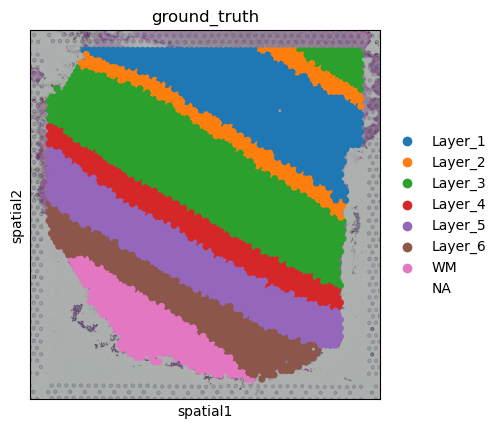

In [8]:
sc.pl.spatial(adata,  color=['ground_truth'],spot_size=150,size=1.3,color_map='viridis', show=True) 

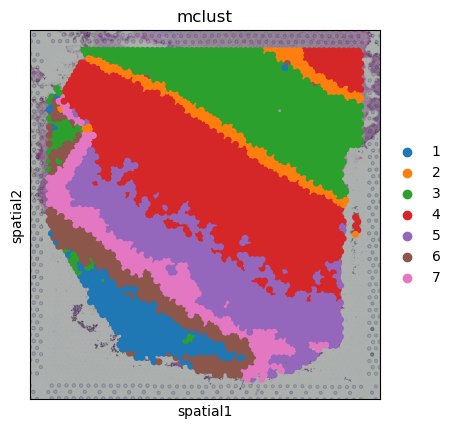

In [9]:
sc.pl.spatial(adata, color=[f'mclust'], spot_size=150, size=1.3, color_map='viridis')